## Summary

1. Feature importance gives insight on features importance that helps on prediction.

#### Implementation for Basic Transformation:
1. Consider to reduce features for prediction, objective to use less sensor on testing which achieving the similar performance.

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
from pathlib import Path

curr_dir = Path.cwd()
proj_root = curr_dir.parent
raw_data = proj_root / "data/raw/uci-secom.csv"

df = pd.read_csv(raw_data)

In [2]:
# Quick Feature Importance Study

new_cols = {
    'timestamp_dt': pd.to_datetime(df['Time']),
    'month_only': pd.to_datetime(df['Time']).dt.month,
    'hour_only' : pd.to_datetime(df['Time']).dt.hour,
}

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

# Sort by the new timestamp column
df = df.sort_values(by='timestamp_dt').reset_index(drop=True)
df['Pass/Fail'] = df['Pass/Fail'].map({-1:0,1:1})

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Data Split (By Time and Dependent Variable)
def stratified_time_split(df, target_col, test_ratio=0.2):
    # 1. Ensure data is sorted by time (SECOM is usually pre-sorted)
    df = df.sort_index() 
    
    # 2. Calculate how many failures we need in the test set
    total_fails = df[target_col].value_counts()[1] # Assuming 1 is 'Fail'
    min_test_fails = int(total_fails * test_ratio)
    
    # 3. Walk backwards from the end of the dataset to find the split point
    fail_count = 0
    split_index = len(df)
    
    for i in range(len(df)-1, 0, -1):
        if df.iloc[i][target_col] == 1:
            fail_count += 1
        if fail_count >= min_test_fails:
            split_index = i
            break
            
    # 4. Split
    train = df.iloc[:split_index]
    test = df.iloc[split_index:]
    
    return train, test

train_df, test_df = stratified_time_split(df, 'Pass/Fail')

In [4]:
ratio = train_df['Pass/Fail'].value_counts().iloc[0] / train_df['Pass/Fail'].value_counts().iloc[1]

X_train = train_df.drop(columns=['Time', 'timestamp_dt', 'Pass/Fail'])
y_train = train_df['Pass/Fail']

# 1. XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=ratio, # Handles imbalance
    importance_type='gain',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 2. LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    is_unbalance=True, # Handles imbalance
    importance_type='gain',
    random_state=42
)
lgbm_model.fit(X_train, y_train)

# 3. CatBoost
cat_model = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    auto_class_weights='Balanced', # Handles imbalance
    verbose=False,
    random_state=42
)
cat_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 84, number of negative: 914
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 95298
[LightGBM] [Info] Number of data points in the train set: 998, number of used features: 466
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.084168 -> initscore=-2.387014
[LightGBM] [Info] Start training from score -2.387014
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

CatBoostClassifier(auto_class_weights='Balanced', depth=4, iterations=200, learning_rate=0.05, random_state=42, verbose=False)

/tmp/ipykernel_60976/1410767711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


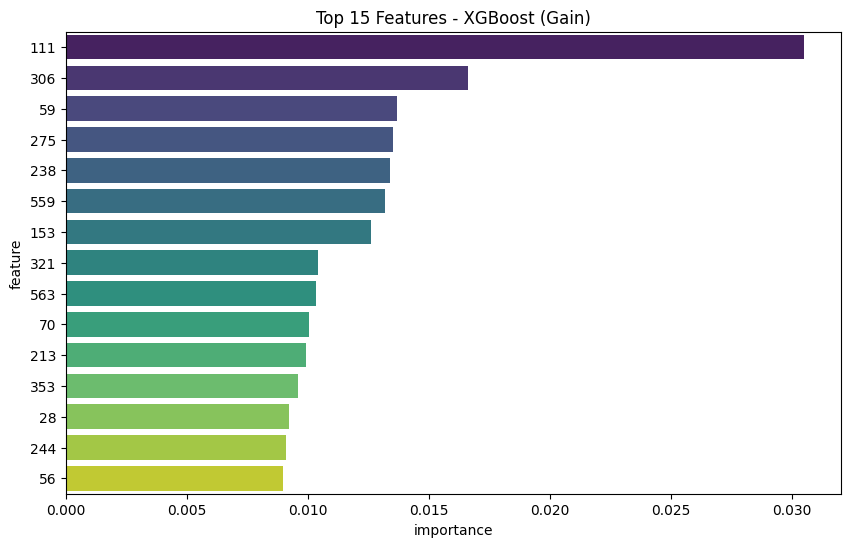

/tmp/ipykernel_60976/1410767711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


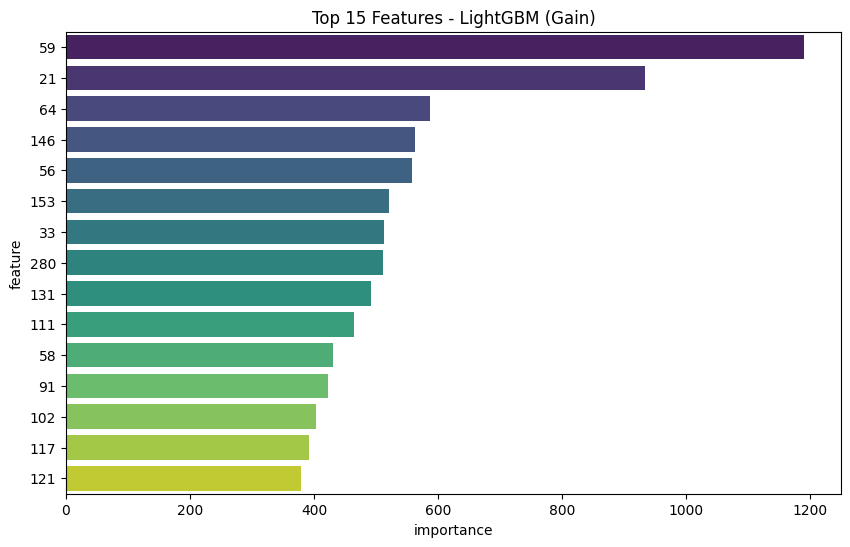

/tmp/ipykernel_60976/1410767711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


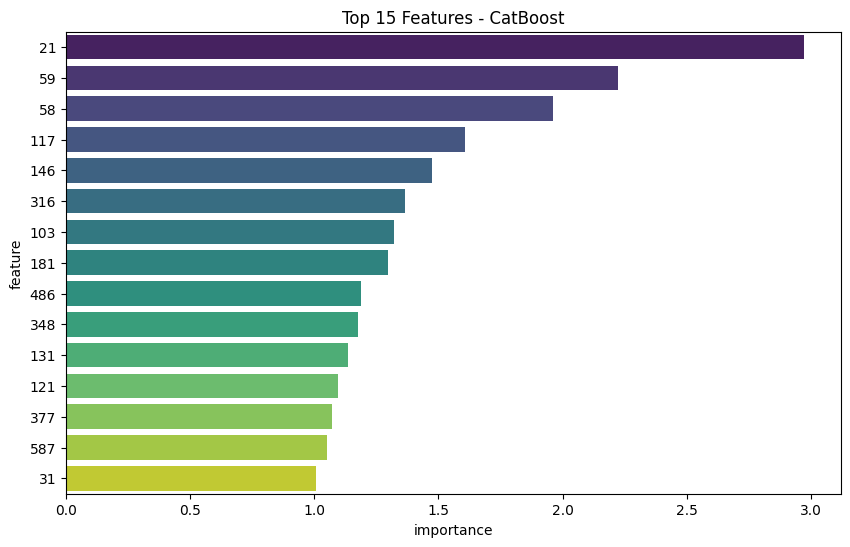

In [5]:
def plot_importance(model, model_name, feature_names, top_n=15):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.get_feature_importance() # CatBoost specific
        
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
    plt.title(f'Top {top_n} Features - {model_name}')
    plt.show()

# Run for all
plot_importance(xgb_model, "XGBoost (Gain)", X_train.columns)
plot_importance(lgbm_model, "LightGBM (Gain)", X_train.columns)
plot_importance(cat_model, "CatBoost", X_train.columns)

In [6]:
X_test = test_df.drop(columns=['Time', 'timestamp_dt', 'Pass/Fail'])
y_test = test_df['Pass/Fail']

/home/desktop/my_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


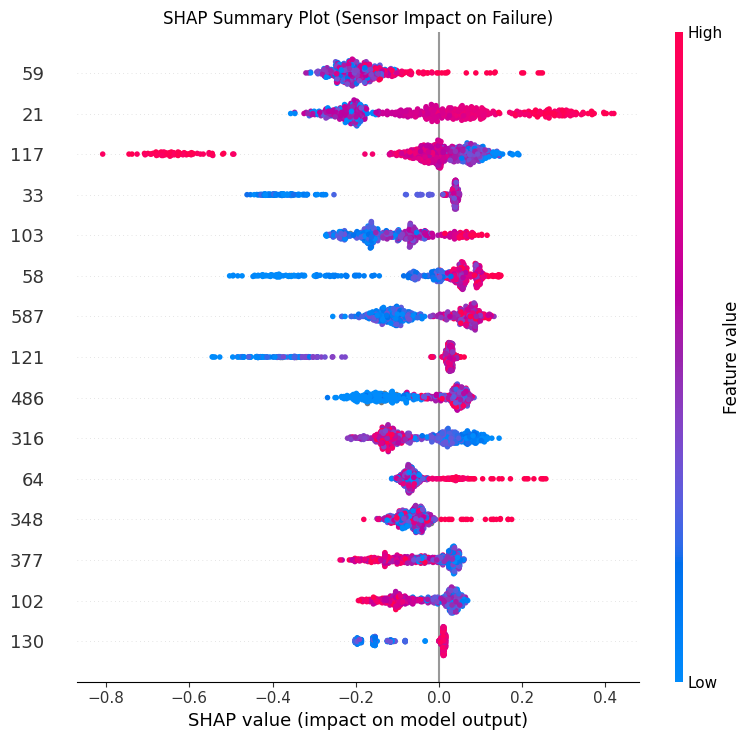

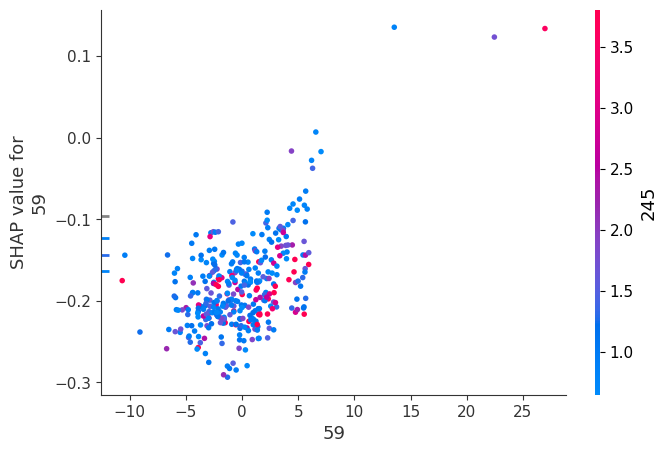

In [7]:
import shap

# We will use the CatBoost model for SHAP as it's robust for small-scale imbalanced data
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot: Shows both importance and the direction of the effect
# Red = High sensor value, Blue = Low sensor value
# Positive SHAP (right) = Higher probability of Fail
plt.title("SHAP Summary Plot (Sensor Impact on Failure)")
shap.summary_plot(shap_values, X_test, max_display=15)

# Dependence Plot: Shows the relationship between one sensor and the target
# Good for seeing thresholds (e.g., "Failure spikes when Sensor 59 > 0.5")
top_feature = X_test.columns[np.argsort(np.abs(shap_values).mean(0))[-1]]
shap.dependence_plot(top_feature, shap_values, X_test)